In [16]:
# import system libraries
import logging
import sys, copy
# import scientific libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.interpolate import InterpolatedUnivariateSpline as spline
import h5py
import pandas as pd
# import data analysis libraries
from ldc.waveform.lisabeta import FastBHB
import lisabeta.lisa.lisa as lisa

from ldc.lisa.noise import AnalyticNoise, get_noise_model
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import lisaconstants
# import sampler libraries
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer

from lisabeta.lisa.lisa import EvaluateTDIFreqseries
import lisabeta.tools.pyspline as pyspline
import lisabeta.lisa.lisatools as lisatools
import lisabeta.tools.pytools as pytools
from ldc.common import tools
from ldc.waveform.waveform import HpHc
import scipy.signal

import LISA_TTL_Functions as foc

mpl.rcParams.update(mpl.rcParamsDefault)

In [17]:
#set up the injection

pMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932, #original 1323277.47932
 'Mass2': 612485.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559, #13470.983559 original
 'ObservationDuration': 31558149.763545603, # 1.0007023643945205 years
 'Cadence': 3.0}

#establish t_min, max, separation and number of samples
t_min = 0
t_max = pMBHB_ldc["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

#set up the injection in lisabeta terms
FBH = FastBHB("MBHB", T=t_max, delta_t=dt, approx="IMRPhenomHM")
pMBHB = FBH.rename_as_lisabeta(pMBHB_ldc)

pMBHB['psi'] += np.pi
pMBHB['phi'] -= np.pi
print('pmbhb:', pMBHB)

#background settings
waveform_params_smbh = {
    "minf": 1e-5,
    "maxf": 1,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "tmax": 1.0,
    "TDI": "TDI2AET",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": False,
    "modes": None,
    # Waveform approximant and set of harmonics to use 
    "approximant": "IMRPhenomHM"
}

#Fvec for interpolation
fmin = 1e-5
fmax = 1
ndata = int(t_max/dt)
df = 1/t_max

# Get the full frequencies
if (ndata % 2)==0:              # Get the number of frequencies
    nfft = int((ndata/2)+1)
else:
    nfft = int((ndata+1)/2)

F = df*nfft                 # make the positive frequency vector
fvec = np.arange(0, F, df)

# Get the frequencies of interest
f_inds = np.where(np.logical_and(fvec >= fmin, fvec < fmax))
fvec = fvec[f_inds]
fvec = fvec[fvec>0]
print('old length of fvec:',len(fvec))

fvec = fvec[::8000]  
fvec = np.ascontiguousarray(fvec)
print('new length of fvec:',len(fvec))

#mask
df = fvec[1]-fvec[0]
n0 = 1 #mask number
n1 = 1



pmbhb: {'beta': -0.30300442294174235, 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'm1': 1323277.47932, 'm2': 612485.5060299999, 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': np.float64(1.2912226019238924), 'inc': np.float64(2.2517895222056112)}
old length of fvec: 11527829
new length of fvec: 1441


In [18]:
#generate data
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, 
                                            gridfreq = fvec,
                                            #scale_freq_hm=False,
                                            **waveform_params_smbh)
tdi = tdisignal['tdi']

modesf  = tdisignal['tdi']['modes']
colors = ['red', 'blue', 'purple', 'magenta', 'green', 'gray']
print(modesf)
A_full = np.zeros(len(fvec), dtype=complex)
E_full = np.zeros(len(fvec), dtype=complex)

for i in range(len(modesf)):
    mbh_lb = tdi[modesf[i]]

    mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
    
    #phase
    splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
    #A
    splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
    splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
    #E
    splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
    splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

    #plot partials
    print(np.where(fvec == min(fvec[mask])))
    A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    plt.loglog(fvec[mask], np.abs(A_partial)**2, label = str(modesf[i]), color = colors[i])
    plt.loglog(fvec[mask], np.abs(E_partial)**2, '--', color = colors[i])
    plt.legend()

    A_full[mask] += A_partial
    E_full[mask] += E_partial

A_full = A_full[n0:-n1]
E_full = E_full[n0:-n1]

Nmodel = AnalyticNoise(fvec, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)

[(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]
(array([0]),)
(array([0]),)
(array([1]),)
(array([0]),)
(array([1]),)
(array([1]),)


In [19]:
Afull = A_full
Efull = E_full
fvec_masked = fvec[n0:-n1]
Npsd_masked = Npsd[n0:-n1]

In [20]:
#now we set things up for mcmc
#solving for chirpmass and ratio
m1 = pMBHB['m1']
m2 = pMBHB['m2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

src0 = pMBHB.copy()
src0["Mchirp"] = Mc
src0["q"] = q
del src0["m1"]
del src0["m2"]

keys = src0.keys()

print(pMBHB)
print(src0)

DA = Afull.copy()
DE = Efull.copy()

{'beta': -0.30300442294174235, 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'm1': 1323277.47932, 'm2': 612485.5060299999, 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': np.float64(1.2912226019238924), 'inc': np.float64(2.2517895222056112)}
{'beta': -0.30300442294174235, 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': np.float64(1.2912226019238924), 'inc': np.float64(2.2517895222056112), 'Mchirp': 772462.8571528315, 'q': 2.160504152820206}


In [21]:
#Interpolated likelihood
def likelihood_interp_sky(pvector):
    src = {k: v for k, v in zip(params, pvector)}

    src['inc'] = np.arccos(src['inc'])
    src['beta'] = np.arcsin(src['beta'])

    
    tdisignal = lisa.GenerateLISATDISignal_SMBH(src, 
                                                gridfreq=fvec, 
                                                #scale_freq_hm=False,
                                                **waveform_params_smbh)
    modesf = tdisignal['tdi']['modes']

    df = fvec[1]-fvec[0]

    hA = np.zeros(len(fvec), dtype=complex)
    hE = np.zeros(len(fvec), dtype=complex)

    for i in range(len(modesf)):
        mbh_lb = tdisignal['tdi'][modesf[i]]

        mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
        
        #phase
        splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
        #A
        splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
        splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
        #E
        splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
        splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

        A_partial = np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
        E_partial = np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))

        hA[mask] += A_partial
        hE[mask] += E_partial

    hA = hA[n0:-n1]
    hE = hE[n0:-n1]

    SN_m = 4.0 * df * np.sum(np.real(DA * np.conjugate(hA)) / Npsd_masked) + 4.0 * df * np.sum(np.real(DE * np.conjugate(hE)) / Npsd_masked)

    XX = 4.0 * df * np.sum(np.abs(hA)**2 / Npsd_masked) + 4.0 * df * np.sum(np.abs(hE)**2 / Npsd_masked)

    loglik = SN_m - 0.5 * XX

    return loglik#, hA

In [22]:
print(src0)
src0['inc'] = np.cos(src0['inc'])
src0['beta'] = np.sin(src0['beta'])
print(src0)
print(pMBHB)

{'beta': -0.30300442294174235, 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': np.float64(1.2912226019238924), 'inc': np.float64(2.2517895222056112), 'Mchirp': 772462.8571528315, 'q': 2.160504152820206}
{'beta': np.float64(-0.29838910344427433), 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': np.float64(1.2912226019238924), 'inc': np.float64(-0.6295649954148954), 'Mchirp': 772462.8571528315, 'q': 2.160504152820206}
{'beta': -0.30300442294174235, 'lambda': 1.2925183861048521, 'chi1': np.float64(0.26863190922667673), 'chi2': np.float64(-0.4215109787709388), 'm1': 1323277.47932, 'm2': 612485.5060299999, 'Deltat': 11526944.921879262, 'phi': -1.9213957675882278, 'dist': 134700.983559, 'psi': 

In [ ]:
import numpy as np
from eryn.ensemble import EnsembleSampler
from eryn.moves import StretchMove
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from eryn.utils import PeriodicContainer

from lisatools.sampling.moves.skymodehop import SkyMove

day_sec = 86400
'''
params = (
    "Mchirp",
    "q",
    "chi1",
    "chi2",
    "dist",
    "phi",
    "inc", #cos inc
    "lambda", # other sky location
    "beta", #sin_beta sky loc
    "psi",
    "Deltat",
)

day_sec = 86400

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(1e4, 1e7), #mchirp
    1: uniform_dist(1, 10), #q
    2: uniform_dist(-0.99, 0.99), #chi1
    3: uniform_dist(-0.99, 0.99), #chi2
    4: uniform_dist(500.0, 2000000.0), #dist 
    5: uniform_dist(0, 2*np.pi), #phi
    6: uniform_dist(0, np.pi), #cos inc 0-pi
    7: uniform_dist(0, np.pi*2), #lambda
    8: uniform_dist(-np.pi, np.pi), #sin beta -pi-pi
    9: uniform_dist(0., np.pi), #psi
    10: uniform_dist(75*day_sec, 175*day_sec), #deltat
})}

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-np.pi/2, np.pi/2), #lambda
    1: uniform_dist(-np.pi, np.pi), #beta
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(75*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(0., np.pi), #inc
    9: uniform_dist(1e4, 1e7), #mchirp 
    10: uniform_dist(1, 10), #q
})}

'''
params = src0.keys()

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-1+1e-8, 1-1e-8),#(-1, 1), #beta
    1: uniform_dist(-np.pi/2, np.pi/2), #lambda
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(75*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(-1+1e-8, 1-1e-8),#(-1, 1), #inc
    9: uniform_dist(1e4, 1e7), #mchirp 
    10: uniform_dist(1, 10), #q
})}

ind_map = {
    "lam":  1,   # lambda (ecliptic longitude)
    "sinbeta": 0,   # ecliptic latitude, stored as sin(beta)
    "psi":  7,   # polarization angle
    "cosinc":  8,   # inclination, stored as cos(inc)
}

start_time = t_min
params = list(keys)

#'''
def make_moves(frame_t0: float = 0.0):
    """Return the historical MBH move cocktail and its selection weights."""
    # SkyMove retains its historical lam/sinbeta key names in ind_map, but the
    # columns hold alpha/sin_delta when coord_frame="icrs".
    sky_indices = {
        "cosinc": params.index("inc"),
        "psi": params.index("psi"),
        "lam": params.index("lambda"),
        "sinbeta": params.index("beta"),
        "t_ref": params.index("Deltat"),
    }
    sky_kwargs = {
        "ind_map": sky_indices,
        "coord_frame": "barycentrictrueecliptic", #icrs
        "frame_t0": frame_t0,
    }
    return [
        (SkyMove(which="both", **sky_kwargs), 0.02),
        (SkyMove(which="long", **sky_kwargs), 0.05),
        (SkyMove(which="lat", **sky_kwargs), 0.05),
        (StretchMove(), 0.88),
    ]
#'''
makemoves = make_moves(start_time)

periodic = PeriodicContainer(
    {
        "mbh": {
            params.index("phi"): 2.0 * np.pi,
            params.index("lambda"): 2.0 * np.pi,
            params.index("psi"): np.pi,
        }
    }
)


moves = [
    (SkyMove(which="both", ind_map=ind_map), 0.02),
    (SkyMove(which="long", ind_map=ind_map), 0.05),
    (SkyMove(which="lat",  ind_map=ind_map), 0.05),
    (StretchMove(), 0.88),
]



from eryn.moves import GaussianMove

gausscov = {'beta':0.051536,
    'lambda':0.058301,
    'chi1':0.007525,
    'chi2':0.018925,
    'Deltat':26.688170,
    'phi':0.136862,
    'dist':6653.573394,
    'psi':0.085216,
    'inc':0.014932,
    'Mchirp':16.381956,
    'q':0.019090}

gausscov_values = np.diag(list(gausscov.values()))**2
attempt2 = np.ones(11)*gausscov_values
factor = 0.00001 # try 1e-2, 1e-3, 1e-4 etc.
cov = {"mbh": attempt2 * factor}
#cov = {"mbh": np.diag(np.ones(11)) * factor}
gauss_move = GaussianMove(cov)


nwalkers = 22
ntemps = 5
nsteps = 30000
ndims = {"mbh": 11}

sample = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood_interp_sky,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps= ntemps),#, "Tmax": np.inf},
    #periodic=periodic,
    #moves = makemoves, #skymove
    moves = gauss_move
    #moves=StretchMove(),
    #vectorize=True,
)



theta = np.array([[np.hstack(
          (np.random.randn(ndims["mbh"])*1e-8) + np.array(list(src0.values())))
          for i in range(nwalkers)]
          for _ in range(ntemps)])

coords = State({"mbh": theta})

#final = sample.run_mcmc(initial_state, nsteps, progress=True)

#coords = priors["mbh"].rvs(size=(ntemps, nwalkers, 1))
#coords = State({"mbh":coords})

sample.run_mcmc(coords, nsteps, progress=True, store = True)

100%|██████████| 3000/3000 [1:37:21<00:00,  1.95s/it]


In [88]:
print(sample.acceptance_fraction)

[[0.68166667 0.69566667 0.69       0.69       0.69266667 0.693
  0.69333333 0.68166667 0.70233333 0.683      0.695      0.68733333
  0.68366667 0.69666667 0.697      0.68933333 0.69466667 0.68566667
  0.68233333 0.69233333 0.69233333 0.68666667]
 [0.76733333 0.752      0.772      0.77466667 0.75333333 0.76333333
  0.76433333 0.763      0.762      0.76533333 0.78933333 0.76333333
  0.76       0.76433333 0.76833333 0.75066667 0.76066667 0.76666667
  0.765      0.77133333 0.759      0.77566667]
 [0.825      0.83133333 0.823      0.82733333 0.82233333 0.83033333
  0.83533333 0.81133333 0.83366667 0.83       0.81566667 0.83166667
  0.83066667 0.82333333 0.83666667 0.84466667 0.82733333 0.83066667
  0.82466667 0.83266667 0.82533333 0.82633333]
 [0.86266667 0.88766667 0.88033333 0.87       0.876      0.88866667
  0.875      0.88633333 0.88033333 0.89       0.884      0.87433333
  0.87366667 0.883      0.87866667 0.87866667 0.869      0.87933333
  0.87633333 0.882      0.88233333 0.87966667]
 

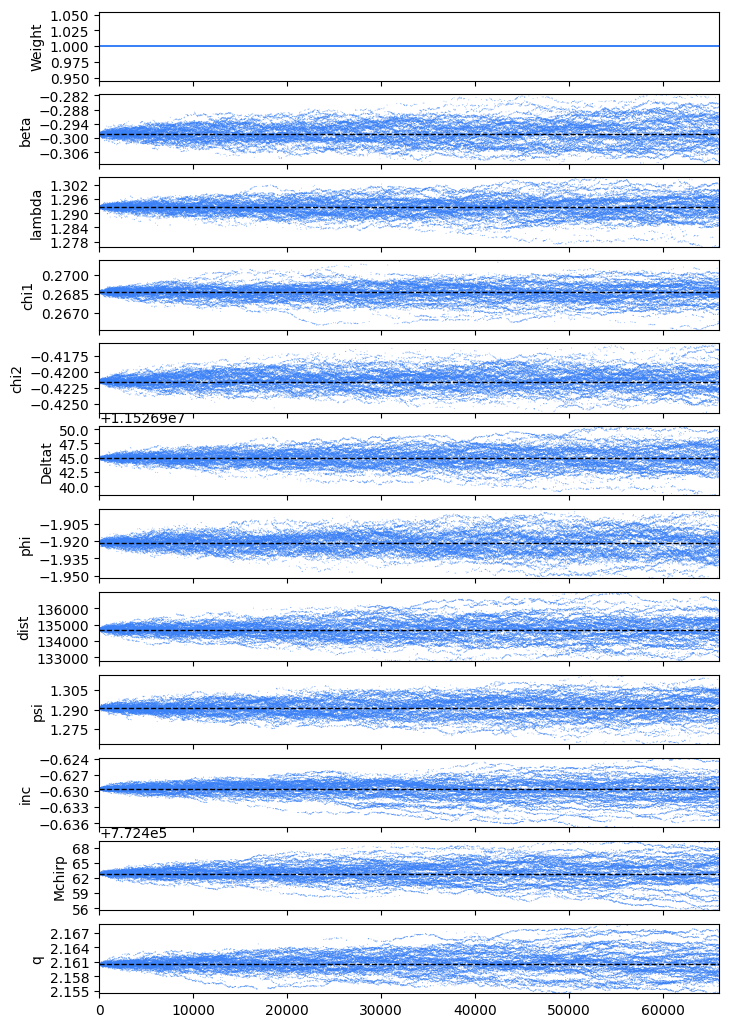

In [89]:
c = ChainConsumer()
burn = 0

truths = src0.values()

samples = sample.get_chain()["mbh"][:, 0].reshape(-1, 11)

ahh = pd.DataFrame(samples[burn:, :], columns = params)

c.add_chain(Chain(samples=ahh, name="noiseless", color="blue"))
c.add_truth(Truth(location={k:v for (k,v) in zip(params,truths)}))

import corner
corner.corner(ahh)

c.plotter.plot()
c.plotter.plot_walks()

In [ ]:
gausscov = np.std(ahh)
print(gausscov)



beta         0.051536
lambda       0.058301
chi1         0.007525
chi2         0.018925
Deltat      26.688170
phi          0.136862
dist      6653.573394
psi          0.085216
inc          0.014932
Mchirp      16.381956
q            0.019090
dtype: float64


/Users/corinnekomlodi/Desktop/Robbie_UV/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
